In [299]:
# Importation des modules nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit


In [300]:
#importer les données
data_height = pd.read_excel(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\ecoulement_libre.xlsx','hauteur_cm')
data_debit = pd.read_excel(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\ecoulement_libre.xlsx','debit')
data_h1 = data_height['debit1']
data_h2 = data_height['debit2']
data_h3 = data_height['debit3']
data_h4 = data_height['debit4']
data_h5 = data_height['debit5']

data_h = [data_h1,data_h2,data_h3,data_h4,data_h5]
herr = 0.5
data_Q = data_debit['debit[cm3/s]']
data_Qerr = data_debit['delta_Q']

l, lerr = 20.7, 0.2
x = [0,1.2,12.2,22.4,28.8,35.5]
xerr= 0.5
#print(data_h1,data_h2,data_h3,data_h4,data_h5)

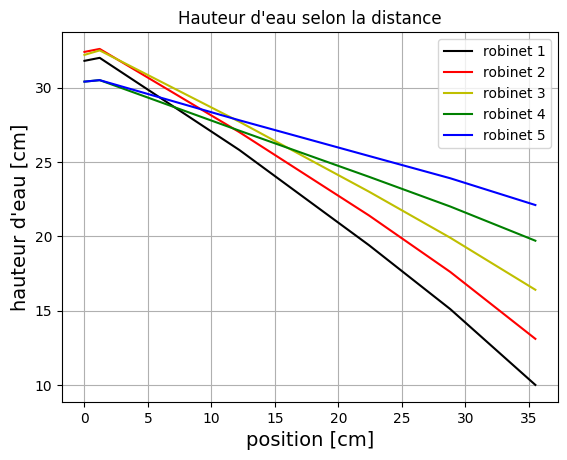

In [301]:
def graphe():
    colors = ['k','r','y','g','b']
    fig,ax = plt.subplots()
    ax.grid()
    ax.set_title(f"Hauteur d'eau selon la distance")
    for n in range (5):
        h = data_h[n]
        #affichage
        ax.plot(x,h,colors[n],label = f'robinet {n+1}')
        ax.set_xlabel('position [cm]',fontsize=14)
        ax.set_ylabel("hauteur d'eau [cm]",fontsize=14)
        plt.legend()

graphe()

In [302]:
def function_for_fit1(x,h2): #H=31.8
    return 31.8**2-h2*x
def function_for_fit2(x,h2): #H=32.4
    return 32.4**2-h2*x
def function_for_fit3(x,h2): #H=32.2
    return 32.2**2-h2*x
def function_for_fit4(x,h2): #H=30.4
    return 30.4**2-h2*x
def function_for_fit5(x,h2): #H=30.4
    return 30.4**2-h2*x
lst_fit_functions = [function_for_fit1, function_for_fit2, function_for_fit3, function_for_fit4, function_for_fit5]

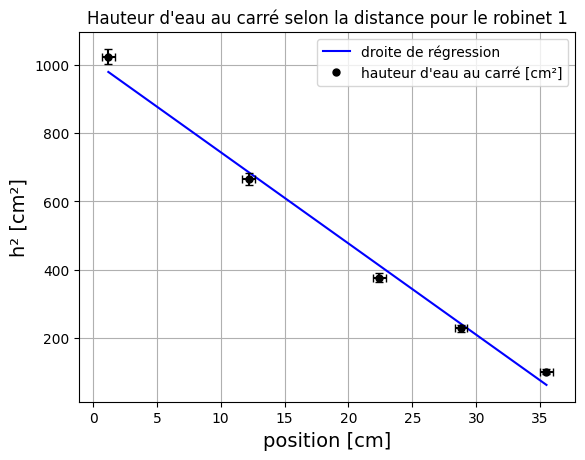

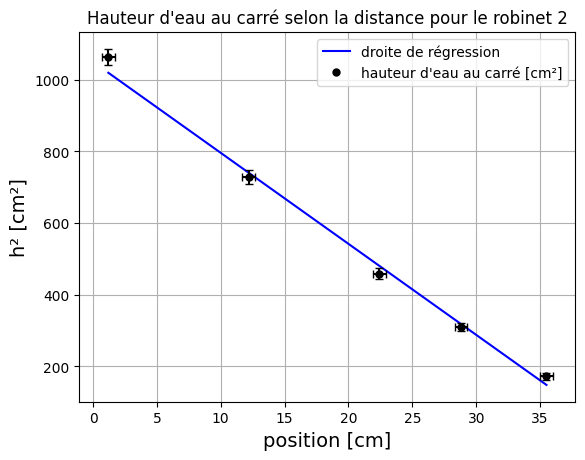

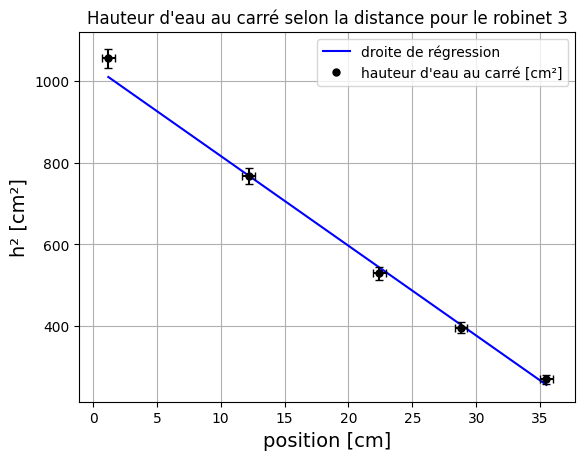

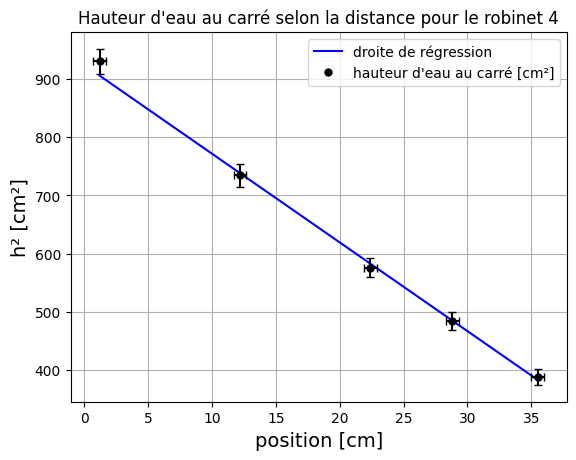

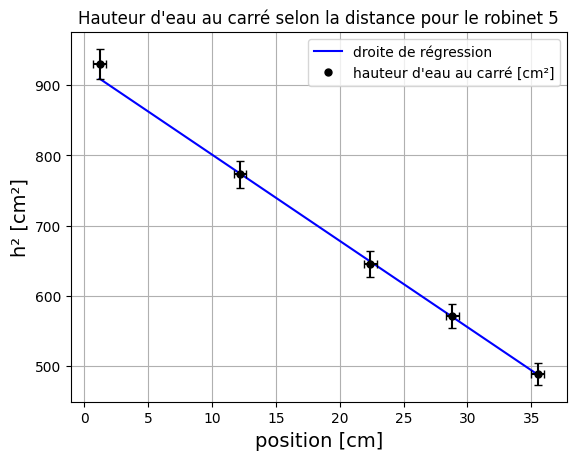

In [303]:
def hauteur_carre(n):
    pos = x[1:]
    h = data_h[n][1:]
    h2 = h**2
    h2err = h2*(2*(herr/h)**2)**(1/2)
    popt,pcov =curve_fit(lst_fit_functions[n],pos,h2)
    pente = popt.squeeze()
    perr = np.sqrt(pcov).squeeze()
    #affichage
    fig,ax = plt.subplots()
    ax.plot(pos,lst_fit_functions[n](pente,pos),'b', label='droite de régression')
    ax.plot(pos,h2,'k',marker='o', linestyle='none',linewidth=0,markersize=5, label = "hauteur d'eau au carré [cm\u00B2]")
    ax.errorbar(pos,h2,yerr=[h2err],xerr=xerr,c='k',linestyle='none',capsize=3)
    ax.set_xlabel('position [cm]',fontsize=14)
    ax.set_ylabel('h\u00B2 [cm\u00B2]',fontsize=14)
    ax.grid()
    ax.set_title(f"Hauteur d'eau au carré selon la distance pour le robinet {n+1}")
    plt.legend()

for k in range(5):
    hauteur_carre(k)

In [306]:
#calcul K et perméabilité intrinsèque k
T = [19.6,14.5,13.4,13.3,13.4]
rho = [998.29,999.26,999.41,999.42,999.41]
mu = [0.001,0.0024,0.0022,0.0022,0.0022]
muerr = 0.0004
g = 9.81
for n in range(5):
    pos = x[1:]
    h = data_h[n][1:]
    h2 = h**2
    h2err = h2*(2*(herr/h)**2)**(1/2)
    Q = data_Q[n]
    Qerr = data_Qerr[n]
    popt,pcov =curve_fit(lst_fit_functions[n],pos,h2)
    pente = popt.squeeze()
    perr = np.sqrt(pcov).squeeze()
    K = 2*Q/(l*pente)
    Kerr = K*((lerr/l)**2+(perr/pente)**2+(Qerr/Q)**2)**(1/2)
    #afficher K
    print(f"K selon le robinet {n+1} vaut: {K} cm/s et l'erreur: {Kerr}")

K selon le robinet 1 vaut: 0.06370855370394579 cm/s et l'erreur: 0.0022022573077984386
K selon le robinet 2 vaut: 0.055218345251660486 cm/s et l'erreur: 0.0018609028073508604
K selon le robinet 3 vaut: 0.057103921376459706 cm/s et l'erreur: 0.0020597215267421027
K selon le robinet 4 vaut: 0.057890561948024555 cm/s et l'erreur: 0.002423383845729808
K selon le robinet 5 vaut: 0.05061250228926606 cm/s et l'erreur: 0.00281432534822713
